In [4]:
import pickle as pkl
import torch
from PIL import Image

# 读取数据
file_path = '/amax/zyude/video_with_human_and_object_results/BV1Bn4y1f76d/clip_448-1028/EMOCA_v2_lr_mse_20/clip/results/000001_000/000001_000_vals.pkl'
with open(file_path, 'rb') as f:
    data = pkl.load(f)

for key, value in data.items():
    print(key, value.shape)

shapecode torch.Size([100])
texcode torch.Size([50])
expcode torch.Size([50])
posecode torch.Size([6])
cam torch.Size([3])
lightcode torch.Size([9, 3])
detailcode torch.Size([128])
detailemocode torch.Size([0])
images torch.Size([3, 224, 224])
predicted_images torch.Size([3, 224, 224])
predicted_detailed_image torch.Size([3, 224, 224])
normals torch.Size([5023, 3])
mask_face_eye torch.Size([1, 224, 224])
verts torch.Size([5023, 3])
albedo torch.Size([3, 256, 256])
landmarks2d torch.Size([68, 3])
landmarks3d torch.Size([68, 3])
predicted_landmarks torch.Size([68, 2])
predicted_landmarks_mediapipe torch.Size([105, 2])
trans_verts torch.Size([5023, 3])
masks torch.Size([1, 224, 224])
uv_texture_gt torch.Size([3, 256, 256])
uv_texture torch.Size([3, 256, 256])
uv_detail_normals torch.Size([3, 256, 256])
uv_shading torch.Size([3, 256, 256])
uv_vis_mask torch.Size([1, 256, 256])
uv_mask torch.Size([1, 256, 256])
uv_z torch.Size([1, 256, 256])
displacement_map torch.Size([1, 256, 256])


In [5]:
import matplotlib.pyplot as plt

def visualize_data(image):
    # 可视化数据
    plt.figure(figsize=(4, 4))
    plt.imshow(image.squeeze(0).permute(1, 2, 0).numpy())  # 将维度从 [3, 224, 224] 转换为 [224, 224, 3]
    plt.axis('off')  # 关闭坐标轴
    plt.show()


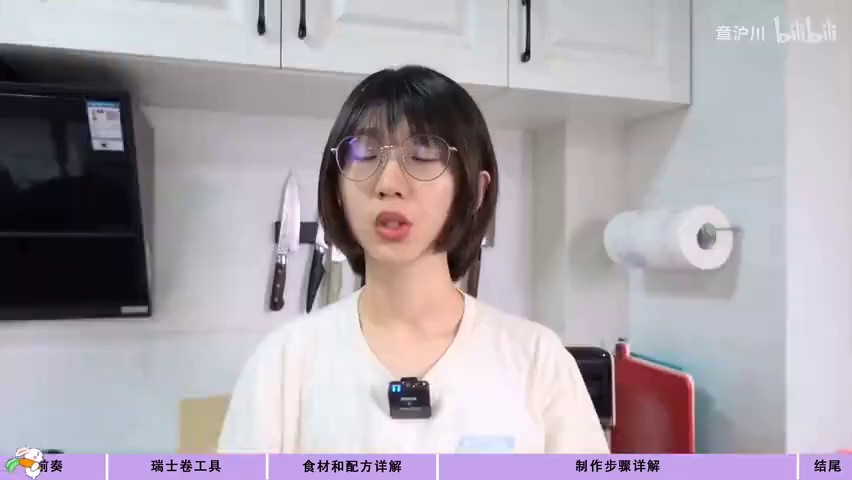

In [6]:
image_path = '/amax/zyude/video_with_human_and_object_results/BV1Bn4y1f76d/clip_448-1028/EMOCA_v2_lr_mse_20/clip/clip/videos/000001.png'
image = Image.open(image_path)
image

In [7]:
shapecode = data['shapecode']
expcode = data['expcode']
posecode = data['posecode']
texcode = data['texcode']
cam = data['cam']
lightcode = data['lightcode']
images = data['images']
if 'masks' in data.keys():
    masks = data['masks']
else:
    masks = None

effective_batch_size = images.shape[0]

In [8]:
import gdl.utils.DecaUtils as util
# 1) Reconstruct the face mesh
# FLAME - world space
verts = data['verts'].unsqueeze(0)

# world to camera
trans_verts = util.batch_orth_proj(verts, cam.unsqueeze(0))

# camera to image space
trans_verts[:, :, 1:] = -trans_verts[:, :, 1:]

albedo = data['albedo']

In [15]:
from gdl.models.Renderer import SRenderY
from pytorch3d.io import load_obj

verts, faces, uv = load_obj('/amax/zyude/video_with_human_and_object_results/BV1Bn4y1f76d/clip_448-1028/EMOCA_v2_lr_mse_20/clip/results/000001_000/mesh_coarse.obj')

trans_verts = util.batch_orth_proj(verts.unsqueeze(0), cam.unsqueeze(0))
trans_verts[:, :, 1:] = -trans_verts[:, :, 1:]
trans_verts.shape
render = SRenderY(224, obj_filename='/amax/zyude/video_with_human_and_object_results/BV1Bn4y1f76d/clip_448-1028/EMOCA_v2_lr_mse_20/clip/results/000001_000/mesh_coarse.obj',
                               uv_size=224)

ops = render(verts.unsqueeze(0), trans_verts, albedo.unsqueeze(0), lightcode.unsqueeze(0))

# images
predicted_images = ops['images']

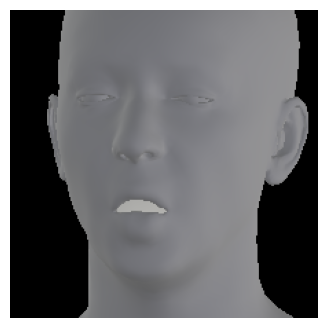

In [10]:
visualize_data(predicted_images)

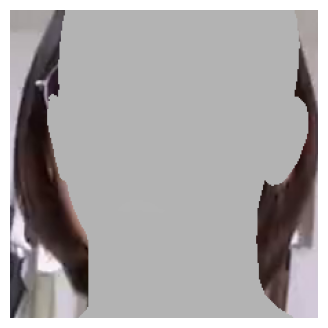

In [11]:
rendered_images = render.render_shape(verts.unsqueeze(0), trans_verts, images=images, lights=lightcode.unsqueeze(0))
visualize_data(rendered_images)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


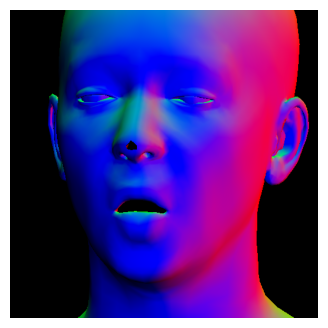

In [47]:
normal_images = render.render_normal(trans_verts, data['normals'].unsqueeze(0))
visualize_data(normal_images)

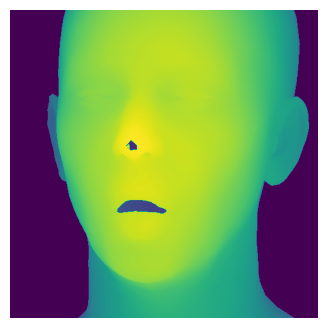

AssertionError: 

In [46]:
depth_images = render.render_depth(trans_verts)
visualize_data(depth_images)


In [ ]:
segmentation_type = None

if isinstance(self.deca.config.useSeg, bool):
    if self.deca.config.useSeg:
        segmentation_type = 'gt'
    else:
        segmentation_type = 'rend'
elif isinstance(self.deca.config.useSeg, str):
    segmentation_type = self.deca.config.useSeg
else:
    raise RuntimeError(f"Invalid 'useSeg' type: '{type(self.deca.config.useSeg)}'")

if segmentation_type not in ["gt", "rend", "intersection", "union"]:
    raise ValueError(f"Invalid segmentation type for masking '{segmentation_type}'")

if masks is None: # if mask not provided, the only mask available is the rendered one
    segmentation_type = 'rend'

elif masks.shape[-1] != predicted_images.shape[-1] or masks.shape[-2] != predicted_images.shape[-2]:
    # resize masks if need be (this is only done if configuration was changed at some point after training)
    dims = masks.ndim == 3
    if dims:
        masks = masks[:, None, :, :]
    masks = F.interpolate(masks, size=predicted_images.shape[-2:], mode='bilinear')
    if dims:
        masks = masks[:, 0, ...]

# resize images if need be (this is only done if configuration was changed at some point after training)
if images.shape[-1] != predicted_images.shape[-1] or images.shape[-2] != predicted_images.shape[-2]:
    ## special case only for inference time if the rendering image sizes have been changed
    images_resized = F.interpolate(images, size=predicted_images.shape[-2:], mode='bilinear')
else:
    images_resized = images

# what type of segmentation we use
if segmentation_type == "gt": # GT stands for external segmetnation predicted by face parsing or similar
    masks = masks[:, None, :, :]
elif segmentation_type == "rend": # mask rendered as a silhouette of the face mesh
    masks = mask_face_eye * ops['alpha_images']
elif segmentation_type == "intersection": # intersection of the two above
    masks = masks[:, None, :, :] * mask_face_eye * ops['alpha_images']
elif segmentation_type == "union": # union of the first two options
    masks = torch.max(masks[:, None, :, :],  mask_face_eye * ops['alpha_images'])
else:
    raise RuntimeError(f"Invalid segmentation type for masking '{segmentation_type}'")


if self.deca.config.background_from_input in [True, "input"]:
    if images.shape[-1] != predicted_images.shape[-1] or images.shape[-2] != predicted_images.shape[-2]:
        ## special case only for inference time if the rendering image sizes have been changed
        predicted_images = (1. - masks) * images_resized + masks * predicted_images
    else:
        predicted_images = (1. - masks) * images + masks * predicted_images
elif self.deca.config.background_from_input in [False, "black"]:
    predicted_images = masks * predicted_images
elif self.deca.config.background_from_input in ["none"]:
    predicted_images = predicted_images
else:
    raise ValueError(f"Invalid type of background modification {self.deca.config.background_from_input}")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


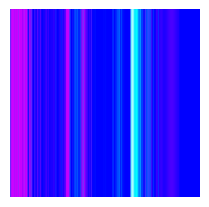

In [23]:
import matplotlib.pyplot as plt
trans_verts = data['trans_verts']
# 将trans_verts可视化为244x244的图片
plt.figure(figsize=(2.44, 2.44))  # 设置图像大小为244x244
plt.imshow(trans_verts, aspect='auto')  # 显示图像
plt.axis('off')  # 关闭坐标轴
plt.show()  # 展示图像
